# **프로젝트: Pose Estimation 모델 비교**

## 1. 라이브러리 호출

In [44]:
# 주의! ray를 pytorch보다 먼저 import하면 오류가 발생할 수 있습니다.
import io
import json
import os
import glob
import math
import time
import random
import gc
import pickle
import psutil
import cv2

# PyTorch 관련 라이브러리
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import models
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from torchinfo import summary

# 데이터 포맷 변환 및 로딩
# TensorFlow의 TFRecord 형식을 
# PyTorch Dataset 인터페이스로 래핑하여 대용량 데이터를 효율적으로 스트리밍
from tfrecord.torch.dataset import TFRecordDataset

# 분산 처리 및 수치 연산
import ray
import numpy as np

# 시각화 및 이미지 처리
from PIL import Image
import matplotlib.pyplot as plt

# 프로젝트 경로 설정
PROJECT_PATH = os.path.join(os.getenv("HOME"), 'work/mpii')
IMAGE_PATH = os.path.join(PROJECT_PATH, 'images')
MODEL_PATH = os.path.join(PROJECT_PATH, 'models')
PT_RECORD_PATH = os.path.join(PROJECT_PATH, 'ptrecords_mpii')
TRAIN_JSON = os.path.join(PROJECT_PATH, 'mpii_human_pose_v1_u12_2', 'train.json')
VALID_JSON = os.path.join(PROJECT_PATH, 'mpii_human_pose_v1_u12_2', 'validation.json')

# 경로 생성 (없을 경우)
os.makedirs(MODEL_PATH, exist_ok=True)

# 라이브러리 버전 확인
print(f"PyTorch version: {torch.__version__}")
print(f"Ray version: {ray.__version__}")

PyTorch version: 2.7.1+cu118
Ray version: 2.54.0


In [2]:
# 랜덤 시드 고정
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed) # 멀티 GPU 사용 시
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ['PYTHONHASHSEED'] = str(seed)

set_seed(42)

In [3]:
# 메모리 사용량 확인 함수
def print_mem_usage():
    # 1. 시스템 메모리 체크 (MEM)
    mem = psutil.virtual_memory()
    total_gb = mem.total / (1024**3)
    used_gb = mem.used / (1024**3)
    percent = mem.percent
    
    print(f"\n[ System Memory ]")
    print(f"Used: {used_gb:.2f}GB / Total: {total_gb:.2f}GB ({percent}%)")
    
    # 2. GPU 메모리 체크
    if torch.cuda.is_available():
        gpu_mem = torch.cuda.memory_allocated() / (1024**3)
        gpu_total = torch.cuda.get_device_properties(0).total_memory / (1024**3)
        print(f"[ GPU Memory ] Used: {gpu_mem:.2f}GB / Total: {gpu_total:.2f}GB")
    
    # 3. 디스크 사용량 체크
    usage = psutil.disk_usage('/')
    print(f"[ Disk Usage ] {usage.percent}% used")
    print("-" * 30)

## 2. 데이터 전처리

각 관절 인덱스가 실제 어느 신체 부위를 나타내는지 알아보기 쉽게 JOINT_NAMES 매핑 변수를 이용해 `관절 인덱스`, `가시성`, `좌표`를 출력한다.

In [4]:
# MPII 데이터셋 관절 명칭 정의
JOINT_NAMES = [
    "0: Right Ankle (오른쪽 발목)", "1: Right Knee (오른쪽 무릎)", "2: Right Hip (오른쪽 골반)", 
    "3: Left Hip (왼쪽 골반)", "4: Left Knee (왼쪽 무릎)", "5: Left Ankle (왼쪽 발목)", 
    "6: Pelvis (골반/치골)", "7: Thorax (가슴/흉곽)", "8: Upper Neck (목 윗부분)", 
    "9: Head Top (머리 꼭대기)", "10: Right Wrist (오른쪽 손목)", "11: Right Elbow (오른쪽 팔꿈치)", 
    "12: Right Shoulder (오른쪽 어깨)", "13: Left Shoulder (왼쪽 어깨)", "14: Left Elbow (왼쪽 팔꿈치)", 
    "15: Left Wrist (왼쪽 손목)"
]

# 데이터 불러오기
with open(TRAIN_JSON) as train_json:
    train_annos = json.load(train_json)
    item = train_annos[0] # 첫 번째 데이터 샘플
    
    print(f"--- [이미지: {item['image']}] 상세 데이터 매핑 ---")
    print(f"Scale: {item['scale']}, Center: {item['center']}")
    print("-" * 50)
    print(f"{'관절 명칭':<25} | {'가시성(Vis)':<10} | {'좌표(x, y)':<15}")
    print("-" * 50)
    
    for i in range(len(JOINT_NAMES)):
        vis = "보임(1)" if item['joints_vis'][i] == 1 else "안보임(0)"
        coord = item['joints'][i]
        # 소수점이 길 경우를 대비해 :.1f로 포맷팅
        print(f"{JOINT_NAMES[i]:<25} | {vis:<12} | ({coord[0]:>6.1f}, {coord[1]:>6.1f})")
    print("-" * 50)

--- [이미지: 015601864.jpg] 상세 데이터 매핑 ---
Scale: 3.021046, Center: [594.0, 257.0]
--------------------------------------------------
관절 명칭                     | 가시성(Vis)   | 좌표(x, y)       
--------------------------------------------------
0: Right Ankle (오른쪽 발목)   | 보임(1)        | ( 620.0,  394.0)
1: Right Knee (오른쪽 무릎)    | 보임(1)        | ( 616.0,  269.0)
2: Right Hip (오른쪽 골반)     | 보임(1)        | ( 573.0,  185.0)
3: Left Hip (왼쪽 골반)       | 보임(1)        | ( 647.0,  188.0)
4: Left Knee (왼쪽 무릎)      | 보임(1)        | ( 661.0,  221.0)
5: Left Ankle (왼쪽 발목)     | 보임(1)        | ( 656.0,  231.0)
6: Pelvis (골반/치골)         | 보임(1)        | ( 610.0,  187.0)
7: Thorax (가슴/흉곽)         | 보임(1)        | ( 647.0,  176.0)
8: Upper Neck (목 윗부분)     | 보임(1)        | ( 637.0,  189.8)
9: Head Top (머리 꼭대기)      | 보임(1)        | ( 696.0,  108.2)
10: Right Wrist (오른쪽 손목)  | 보임(1)        | ( 606.0,  217.0)
11: Right Elbow (오른쪽 팔꿈치) | 보임(1)        | ( 553.0,  161.0)
12: Right Shoulder (오른쪽 어깨) | 보임(1)       

In [5]:
def parse_one_annotation(anno, image_dir):
    filename = anno['image']
    joints = anno['joints']
    joints_visibility = anno['joints_vis']
    annotation = {
        'filename': filename,
        'filepath': os.path.join(image_dir, filename),
        'joints_visibility': joints_visibility,
        'joints': joints,
        'center': anno['center'],
        'scale' : anno['scale']
    }
    return annotation

In [6]:
# parse_one_annotation 함수 테스트
with open(TRAIN_JSON) as train_json:
    train_annos = json.load(train_json)
    test = parse_one_annotation(train_annos[0], IMAGE_PATH)
    print(test)

{'filename': '015601864.jpg', 'filepath': '/home/jovyan/work/mpii/images/015601864.jpg', 'joints_visibility': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], 'joints': [[620.0, 394.0], [616.0, 269.0], [573.0, 185.0], [647.0, 188.0], [661.0, 221.0], [656.0, 231.0], [610.0, 187.0], [647.0, 176.0], [637.0201, 189.8183], [695.9799, 108.1817], [606.0, 217.0], [553.0, 161.0], [601.0, 167.0], [692.0, 185.0], [693.0, 240.0], [688.0, 313.0]], 'center': [594.0, 257.0], 'scale': 3.021046}


## 3. DataLoader 파일 만들기

In [7]:
def generate_ptexample(anno):
    filename = anno['filename']
    filepath = anno['filepath']

    # 이미지 파일 읽기
    with open(filepath, 'rb') as image_file:
        content = image_file.read()

    image = Image.open(filepath)
    # JPEG 형식 및 RGB 모드가 아니면 변환
    if image.format != 'JPEG' or image.mode != 'RGB':
        image_rgb = image.convert('RGB')
        with io.BytesIO() as output:
            image_rgb.save(output, format="JPEG", quality=95)
            content = output.getvalue()

    width, height = image.size
    depth = 3

    c_x = int(anno['center'][0])
    c_y = int(anno['center'][1])
    scale = anno['scale']

    x = [int(joint[0]) if joint[0] >= 0 else int(joint[0])
         for joint in anno['joints']]
    y = [int(joint[1]) if joint[1] >= 0 else int(joint[0])
         for joint in anno['joints']]

    v = [0 if joint_v == 0 else 2 for joint_v in anno['joints_visibility']]

    feature = {
        'image/height': height,
        'image/width': width,
        'image/depth': depth,
        'image/object/parts/x': x,
        'image/object/parts/y': y,
        'image/object/center/x': c_x,
        'image/object/center/y': c_y,
        'image/object/scale': scale,
        'image/object/parts/v': v,
        'image/encoded': content,
        'image/filename': filename.encode()  # bytes로 저장
    }

    return feature

In [8]:
def chunkify(l, n):
    size = len(l) // n
    start = 0
    results = []
    for i in range(n):
        results.append(l[start:start + size])
        start += size
    return results

In [9]:
test_chunks = chunkify([0] * 1000, 64)
print(test_chunks)
print(len(test_chunks))
print(len(test_chunks[0]))

[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0,

In [10]:
@ray.remote
def build_single_ptrecord(chunk, path):
    """
    기존의 pickle 저장 방식을 유지하면서 메모리 관리 로직을 추가한 함수
    [메모리 최적화 전략]
    1. Streaming Write: 데이터를 리스트에 쌓지 않고 즉시 pickle.dump하여 RAM 점유 최소화
    2. Explicit Deletion: pickle 기록 직후 객체 참조를 제거하여 메모리 해제 유도
    3. Manual GC: 워커 프로세스 종료 전 gc.collect()를 호출하여 /dev/shm 부족 환경 대응
    """
    # 경로에 폴더가 없다면 생성
    os.makedirs(os.path.dirname(path), exist_ok=True)
    
    print(f'Start to build ptrecord for {path}')

    try:
        with open(path, 'wb') as writer:
            for anno in chunk:
                # 노트북에 정의된 generate_ptexample 호출
                ptexample = generate_ptexample(anno)
                # 기존 방식대로 pickle을 사용하여 기록
                # 바이너리 형태로 직렬화하여 저장하기 때문에 
                # 텍스트(JSON) 방식보다 I/O 속도가 빠름 
                # 학습 시 DataLoader에서 역직렬화(Unpickling)를 통해 
                # 원본 객체로 빠르게 복원할 수 있음
                pickle.dump(ptexample, writer)
                
                # 즉시 메모리 해제 유도
                del ptexample
        
        print(f'Finished building ptrecord for {path}')
        
    except Exception as e:
        print(f"Error building ptrecord at {path}: {e}")
        return None
    
    finally:
        # 워커 내부 메모리 강제 정리
        gc.collect()
        
    return path

In [11]:
def build_pt_records(annotations, total_shards, split):
    # 1. 데이터를 샤드 개수만큼 분할
    chunks = chunkify(annotations, total_shards)
    
    # 2. .ptrecords 확장자와 f-string 포맷을 유지하여 병렬 작업 생성
    futures = [
        build_single_ptrecord.remote(
            chunk, 
            os.path.join(PT_RECORD_PATH, f'{split}_{str(i + 1).zfill(4)}_of_{str(total_shards).zfill(4)}.ptrecords')
        ) for i, chunk in enumerate(chunks)
    ]
    
    # 3. Ray를 통해 병렬 처리가 완료될 때까지 대기 및 결과 수집
    results = ray.get(futures)
    
    # 4. 성공한 샤드 개수 출력
    success_count = len([r for r in results if r is not None])
    print(f'Successfully wrote {success_count} PT Records for {split}.')
    
    # 5. [메모리 최적화] 메인 프로세스의 잔여 메모리 강제 정리
    gc.collect()

In [12]:
class MPIIDataset(Dataset):
    def __init__(self, ptrecord_dir, split, transform=None):
        self.transform = transform
        self.samples = [] # 데이터 자체가 아닌, '데이터를 찾을 위치 정보'를 저장

        # ptrecords 파일 리스트 확보
        file_pattern = os.path.join(ptrecord_dir, f'{split}_*.ptrecords')
        files = sorted(glob.glob(file_pattern))
        
        # 메모리 보존을 위해 파일 경로와 오프셋(위치)만 저장하거나, 
        # 일단은 작은 데이터(좌표 등)만 로드하고 이미지는 필요할 때만 읽어야 함
        # 파일 분할 로드 방식 적용
        for file_path in files:
            with open(file_path, 'rb') as f:
                while True:
                    try:
                        # 파일 내에서 현재 읽기 포인터의 위치 저장
                        pos = f.tell()
                        data = pickle.load(f)
                        # 실제 이미지는 빼고, 파일 경로와 위치(pos)만 기록
                        self.samples.append((file_path, pos))
                    except EOFError:
                        break

        # [수정 포인트] 데이터를 절반으로 슬라이싱 (앞의 50%만 사용)
        # 22208개 -> 11104개 배치로 감소
        self.samples = self.samples[:len(self.samples) // 2]
        
        print(f"Successfully indexed {len(self.samples)} samples. RAM is safe!")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        # 1. 저장해둔 샤드 파일 경로와 위치로 가서 해당 데이터만 읽어옴
        file_path, pos = self.samples[idx]
        with open(file_path, 'rb') as f:
            f.seek(pos)
            feature = pickle.load(f)

        # 2. 바이너리로 저장된 이미지를 PIL 이미지로 복원
        image_raw = feature['image/encoded']
        image = Image.open(io.BytesIO(image_raw)).convert('RGB')

        # 3. transform 단계에서 필요한 형식으로 변환 (anno dict 재구성)
        # transform 함수가 기존 annotation 키를 사용하므로 형식을 맞춰줌
        anno_converted = {
            'joints': list(zip(feature['image/object/parts/x'], feature['image/object/parts/y'])),
            'joints_visibility': feature['image/object/parts/v'],
            'center': [feature['image/object/center/x'], feature['image/object/center/y']],
            'scale': feature['image/object/scale']
        }

        if self.transform:
            # {'image': PIL이미지, 'annotation': 파싱된 정보}
            image, heatmaps = self.transform({'image': image, 'annotation': anno_converted})
            return image, heatmaps
        return image, anno_converted

In [13]:
%%time

# 1. Ray 초기화 및 시스템 설정 (메모리 제약 대응)
if ray.is_initialized():
    ray.shutdown()

ray.init(
    # 공유 메모리가 부족할 경우 디스크(/tmp)를 캐시로 사용하도록 설정
    _system_config={
        "object_spilling_config": json.dumps(
            {"type": "filesystem", "params": {"directory_path": "/tmp/ray_spill"}}
        ),
    },
    # 컨테이너 환경의 메모리 제한을 고려하여 객체 저장소 용량 보수적 설정
    object_store_memory=1024 * 1024 * 100  # 100MB
)

# 2. 경로 설정 및 어노테이션 파싱
num_train_shards = 64
num_val_shards = 8

if not os.path.exists(PT_RECORD_PATH):
    os.makedirs(PT_RECORD_PATH)

print('Start to parse annotations.')

# Train Annotations 로드
with open(TRAIN_JSON) as train_json:
    train_annos = json.load(train_json)
    train_annotations = [
        parse_one_annotation(anno, IMAGE_PATH)
        for anno in train_annos
    ]
    print('First train annotation: ', train_annotations[0])

# Validation Annotations 로드
with open(VALID_JSON) as val_json:
    val_annos = json.load(val_json)
    val_annotations = [
        parse_one_annotation(anno, IMAGE_PATH)
        for anno in val_annos
    ]
    print('First val annotation: ', val_annotations[0])

# 3. 최적화된 로직으로 PT Records 구축 시작
print('Start to build PT Records with memory optimization...')

# 앞에서 수정한 build_pt_records 함수 호출
build_pt_records(train_annotations, num_train_shards, 'train')
build_pt_records(val_annotations, num_val_shards, 'val')

print('-' * 30)
print('Successfully wrote {} annotations to PT Records.'.format(
    len(train_annotations) + len(val_annotations)))

# 작업 완료 후 Ray 종료하여 메모리 해제
ray.shutdown()

# 메모리 사용량 확인
print_mem_usage()

2026-03-03 23:56:01,709	WARNING node.py:1794 -- The object spilling config is specified from an unstable API - system config or environment variable. This is subject to change in the future. You can use the stable API - --object-spilling-directory in ray start or object_spilling_directory in ray.init() to specify the object spilling directory instead. If you need more advanced settings, please open a github issue with the Ray team.
2026-03-03 23:56:04,575	WARNING services.py:2168 -- WARNING: The object store is using /tmp instead of /dev/shm because /dev/shm has only 67108864 bytes available. This will harm performance! You may be able to free up space by deleting files in /dev/shm. If you are inside a Docker container, you can increase /dev/shm size by passing '--shm-size=0.11gb' to 'docker run' (or add it to the run_options list in a Ray cluster config). Make sure to set this to more than 30% of available RAM.
2026-03-03 23:56:06,758	INFO worker.py:2013 -- Started a local Ray instanc

Start to parse annotations.
First train annotation:  {'filename': '015601864.jpg', 'filepath': '/home/jovyan/work/mpii/images/015601864.jpg', 'joints_visibility': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], 'joints': [[620.0, 394.0], [616.0, 269.0], [573.0, 185.0], [647.0, 188.0], [661.0, 221.0], [656.0, 231.0], [610.0, 187.0], [647.0, 176.0], [637.0201, 189.8183], [695.9799, 108.1817], [606.0, 217.0], [553.0, 161.0], [601.0, 167.0], [692.0, 185.0], [693.0, 240.0], [688.0, 313.0]], 'center': [594.0, 257.0], 'scale': 3.021046}
First val annotation:  {'filename': '005808361.jpg', 'filepath': '/home/jovyan/work/mpii/images/005808361.jpg', 'joints_visibility': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], 'joints': [[804.0, 711.0], [816.0, 510.0], [908.0, 438.0], [1040.0, 454.0], [906.0, 528.0], [883.0, 707.0], [974.0, 446.0], [985.0, 253.0], [982.7591, 235.9694], [962.2409, 80.0306], [869.0, 214.0], [798.0, 340.0], [902.0, 253.0], [1067.0, 253.0], [1167.0, 353.0], [1142.0, 478.0

### data label 만들기

In [14]:
feature_description = {
    'image/height': 'int',
    'image/width': 'int',
    'image/depth': 'int',
    'image/object/parts/x': 'int',
    'image/object/parts/y': 'int',
    'image/object/parts/v': 'int',
    'image/object/center/x': 'int',
    'image/object/center/y': 'int',
    'image/object/scale': 'float',
    'image/encoded': 'byte',
    'image/filename': 'byte',
}

In [15]:
def crop_roi(image, features, margin=0.2):
    img_height, img_width, img_depth = image.shape

    keypoint_x = torch.tensor(features['image/object/parts/x'], dtype=torch.int32)
    keypoint_y = torch.tensor(features['image/object/parts/y'], dtype=torch.int32)
    center_x = features['image/object/center/x']
    center_y = features['image/object/center/y']
    body_height = features['image/object/scale'] * 200.0

    # 유효한 keypoint (값이 0보다 큰 값)만 선택합니다.
    masked_keypoint_x = keypoint_x[keypoint_x > 0]
    masked_keypoint_y = keypoint_y[keypoint_y > 0]

    # 최소, 최대 값 계산 (유효한 keypoint가 하나 이상 있다고 가정)
    keypoint_xmin = masked_keypoint_x.min()
    keypoint_xmax = masked_keypoint_x.max()
    keypoint_ymin = masked_keypoint_y.min()
    keypoint_ymax = masked_keypoint_y.max()

    # margin을 적용하여 경계를 확장 (body_height * margin 값을 정수로 캐스팅)
    extra = int(body_height * margin)
    xmin = int(keypoint_xmin.item()) - extra
    xmax = int(keypoint_xmax.item()) + extra
    ymin = int(keypoint_ymin.item()) - extra
    ymax = int(keypoint_ymax.item()) + extra

    # 이미지 경계를 벗어나지 않도록 조정
    effective_xmin = xmin if xmin > 0 else 0
    effective_ymin = ymin if ymin > 0 else 0
    effective_xmax = xmax if xmax < img_width else img_width
    effective_ymax = ymax if ymax < img_height else img_height

    # 이미지 크기 재조정
    cropped_image = image[effective_ymin:effective_ymax, effective_xmin:effective_xmax, :]
    new_height, new_width, _ = cropped_image.shape

    # keypoint 좌표를 정규화 (0~1 범위)
    effective_keypoint_x = (keypoint_x.float() - effective_xmin) / new_width
    effective_keypoint_y = (keypoint_y.float() - effective_ymin) / new_height

    return cropped_image, effective_keypoint_x, effective_keypoint_y

In [16]:
def generate_2d_gaussian(height, width, y0, x0, visibility=2, sigma=1, scale=12):
    # (height, width) 크기의 0으로 채워진 heatmap 생성
    heatmap = torch.zeros((height, width), dtype=torch.float32)

    xmin = x0 - 3 * sigma
    ymin = y0 - 3 * sigma
    xmax = x0 + 3 * sigma
    ymax = y0 + 3 * sigma

    # 범위가 이미지 내에 없거나, visibility가 0이면 heatmap 그대로 반환
    if xmin >= width or ymin >= height or xmax < 0 or ymax < 0 or visibility == 0:
        return heatmap

    size = int(6 * sigma + 1)
    grid_range = torch.arange(0, size, dtype=torch.float32)
    x_grid, y_grid = torch.meshgrid(grid_range, grid_range, indexing='xy')
    center_x = size // 2
    center_y = size // 2

    # 가우시안 patch 계산
    gaussian_patch = torch.exp(-(((x_grid - center_x)**2 + (y_grid - center_y)**2) / (sigma**2 * 2))) * scale

    # 이미지와 patch 간의 겹치는 영역 계산
    patch_xmin = max(0, -xmin)
    patch_ymin = max(0, -ymin)
    patch_xmax = min(xmax, width) - xmin
    patch_ymax = min(ymax, height) - ymin

    heatmap_xmin = max(0, xmin)
    heatmap_ymin = max(0, ymin)
    heatmap_xmax = min(xmax, width)
    heatmap_ymax = min(ymax, height)

    # 계산된 영역에 gaussian_patch 값을 할당
    heatmap[heatmap_ymin:heatmap_ymax, heatmap_xmin:heatmap_xmax] = \
        gaussian_patch[int(patch_ymin):int(patch_ymax), int(patch_xmin):int(patch_xmax)]

    return heatmap

In [17]:
def make_heatmaps(features, keypoint_x, keypoint_y, heatmap_shape):
    # heatmap_shape: (H, W, C) 가정
    h_h, h_w, h_c = heatmap_shape
    
    v = torch.tensor(features['image/object/parts/v'], dtype=torch.float32)
    # 정규화된 좌표를 heatmap 크기에 맞게 스케일링
    # 좌표가 0~1 사이를 벗어날 경우를 대비해 clamp 적용
    x = torch.clamp(torch.round(keypoint_x * (h_w - 1)), 0, h_w - 1).to(torch.int32)
    y = torch.clamp(torch.round(keypoint_y * (h_h - 1)), 0, h_h - 1).to(torch.int32)

    heatmaps_list = []
    for i in range(h_c):
        # visibility가 0이면(안 보이면) 빈 heatmap 추가
        if v[i] == 0:
            heatmaps_list.append(torch.zeros((h_h, h_w), dtype=torch.float32))
            continue

        # generate_2d_gaussian 함수 호출 시, height=heatmap_shape[1], width=heatmap_shape[0]
        gaussian = generate_2d_gaussian(
            h_h, h_w, 
            int(y[i].item()), 
            int(x[i].item()), 
            visibility=int(v[i].item()),
            sigma=1.5 # sigma 값을 1.5 정도로 주면 학습이 더 잘 됩니다
        )
        heatmaps_list.append(gaussian)

    # (C, H, W) -> (H, W, C) 전치
    heatmaps = torch.stack(heatmaps_list, dim=0).permute(1, 2, 0)
    return heatmaps

In [18]:
class Preprocessor(object):
    def __init__(self,
                 image_shape=(256, 256, 3),
                 heatmap_shape=(64, 64, 16),
                 is_train=False):
        self.is_train = is_train
        self.image_shape = image_shape
        self.heatmap_shape = heatmap_shape

    def __call__(self, example):
        # 1. 데이터 파싱
        features = example['annotation'] 
        if isinstance(example['image'], bytes):
            image = Image.open(io.BytesIO(example['image'])).convert('RGB')
        else:
            image = example['image']

        # 2. ROI Crop
        if self.is_train:
            random_margin = torch.empty(1).uniform_(0.1, 0.3).item()
            image, keypoint_x, keypoint_y = self.crop_roi(image, features, margin=random_margin)
        else:
            image, keypoint_x, keypoint_y = self.crop_roi(image, features, margin=0.2)

        # 3. 리사이즈 및 정규화
        image = image.resize((self.image_shape[1], self.image_shape[0]))
        image_np = np.array(image).astype(np.float32)
        image_np = image_np / 127.5 - 1.0
        image_tensor = torch.from_numpy(image_np).permute(2, 0, 1)

        # 4. 히트맵 생성
        heatmaps = self.make_heatmaps(features, keypoint_x, keypoint_y, self.heatmap_shape)

        # 정성적 평가를 위해 이미지와 히트맵 2개를 리턴
        return image_tensor, heatmaps

    def _apply_patch(self, heatmap, patch, x, y, size):
        """
        텐서 크기 불일치 에러를 방지하는 슬라이싱 방식 적용
        """
        h, w = heatmap.shape
        
        # 1. 히트맵 영역 계산
        x_start, x_end = max(0, x - size), min(w, x + size + 1)
        y_start, y_end = max(0, y - size), min(h, y + size + 1)
        
        # 2. 패치 영역 계산
        p_x_start = max(0, -(x - size))
        p_y_start = max(0, -(y - size))
        
        # 3. 실제 복사할 크기를 명시적으로 계산
        target_h = y_end - y_start
        target_w = x_end - x_start
        
        # 4. 크기가 0보다 클 때만 대입 (패치에서 필요한 만큼만 잘라서 넣음)
        if target_h > 0 and target_w > 0:
            # patch[p_y_start:p_y_end] 대신 target_h를 사용하여 강제로 크기 일치
            heatmap[y_start:y_end, x_start:x_end] = patch[p_y_start:p_y_start + target_h, p_x_start:p_x_start + target_w]
            
        return heatmap

    def crop_roi(self, image, features, margin=0.2):
        img_w, img_h = image.size
        
        # 좌표를 텐서로 변환
        keypoint_x = torch.tensor(features['joints'], dtype=torch.float32)[:, 0]
        keypoint_y = torch.tensor(features['joints'], dtype=torch.float32)[:, 1]
        v = torch.tensor(features['joints_visibility'], dtype=torch.float32)
        
        body_height = features['scale'] * 200.0

        # 가시성이 있는 관절들로만 경계 계산
        masked_x = keypoint_x[v > 0]
        masked_y = keypoint_y[v > 0]

        if len(masked_x) > 0:
            xmin, xmax = masked_x.min().item(), masked_x.max().item()
            ymin, ymax = masked_y.min().item(), masked_y.max().item()
        else:
            # 관절이 하나도 안 보일 경우 센터 기준 기본값
            xmin = ymin = 0
            xmax, ymax = img_w, img_h

        extra = int(body_height * margin)
        
        # 최종 Crop 영역 결정
        left = max(0, xmin - extra)
        top = max(0, ymin - extra)
        right = min(img_w, xmax + extra)
        bottom = min(img_h, ymax + extra)

        cropped_image = image.crop((left, top, right, bottom))
        
        # 정규화된 좌표 계산 (0 ~ 1)
        new_w = right - left
        new_h = bottom - top
        
        # 0으로 나누기 방지
        new_w = new_w if new_w > 0 else 1
        new_h = new_h if new_h > 0 else 1

        effective_x = (keypoint_x - left) / new_w
        effective_y = (keypoint_y - top) / new_h

        return cropped_image, effective_x, effective_y

    def generate_2d_guassian(self, height, width, y0, x0, visibility=2, sigma=1.5, scale=12):
        heatmap = torch.zeros((height, width), dtype=torch.float32)
        
        if visibility == 0:
            return heatmap

        # 정수형 좌표로 변환 (인덱싱을 위해)
        x0, y0 = int(x0), int(y0)

        # 가우시안 중심이 맵 안에 있도록 제한
        x0 = max(0, min(width - 1, x0))
        y0 = max(0, min(height - 1, y0))

        # [수정] size를 항상 홀수로 만들어 중심(center)을 대칭으로 설정
        # sigma=1.5일 때 size=9, center=4가 되어 좌우 4칸씩 대칭을 이룸
        size = int(6 * sigma) 
        if size % 2 == 0: size += 1 
        
        grid_range = torch.arange(0, size, dtype=torch.float32)
        x_grid, y_grid = torch.meshgrid(grid_range, grid_range, indexing='xy')
        
        center = size // 2
        gaussian_patch = torch.exp(-(((x_grid - center)**2 + (y_grid - center)**2) / (2 * sigma**2))) * scale

        return self._apply_patch(heatmap, gaussian_patch, x0, y0, center)

    def _apply_patch(self, heatmap, patch, x0, y0, half_s):
        h, w = heatmap.shape
        
        # 1. 히트맵 상의 유효 범위 계산
        x_start, x_end = max(0, x0 - half_s), min(w, x0 + half_s + 1)
        y_start, y_end = max(0, y0 - half_s), min(h, y0 + half_s + 1)
        
        # 2. 패치 상의 유효 범위 계산
        # 맵 밖으로 나가는 만큼 패치에서도 잘라내야 함
        p_x_start = max(0, half_s - x0)
        p_y_start = max(0, half_s - y0)
        
        # 3. 실제 복사될 크기 계산 (중요: target_h/w 만큼만 잘라옴)
        target_h = y_end - y_start
        target_w = x_end - x_start
        
        if target_h > 0 and target_w > 0:
            # patch[p_y_start:p_y_end] 방식 대신 실제 필요한 크기(target)만큼 슬라이싱
            heatmap[y_start:y_end, x_start:x_end] = patch[p_y_start:p_y_start + target_h, p_x_start:p_x_start + target_w]
            
        return heatmap

    def make_heatmaps(self, features, keypoint_x, keypoint_y, heatmap_shape):
        h, w, c = heatmap_shape
        v = torch.tensor(features['joints_visibility'], dtype=torch.float32)
        
        # 정규화된 좌표를 Heatmap 해상도에 매핑
        x = torch.round(keypoint_x * (w - 1)).to(torch.int32)
        y = torch.round(keypoint_y * (h - 1)).to(torch.int32)

        heatmaps_list = []
        for i in range(c):
            gaussian = self.generate_2d_guassian(h, w, y[i].item(), x[i].item(), visibility=v[i].item())
            heatmaps_list.append(gaussian)

        return torch.stack(heatmaps_list, dim=0) # (C, H, W)

- 불필요한 인코딩 제거:  
image_to_bytes를 호출해서 다시 로드하는 과정은 매우 느리다. 이미 메모리에 이미지가 있다면 바로 사용하도록 수정했다.

- 좌표 안정성 확보:  
torch.clamp와 유효성 검사를 통해, 관절이 이미지 밖으로 나갔을 때 인덱스 에러가 발생하여 학습이 멈추는 현상을 방지했다.

- 채널 순서(Permute):  
PyTorch 모델은 입력으로 (Channel, Height, Width)를 기대하므로 마지막에 permute(2, 0, 1)을 통해 이를 확실히 맞췄다.

- Heatmap 시각화 최적화:  
sigma 값을 1.5 정도로 약간 키우면 모델이 초기 단계에서 관절 위치를 학습하는 데 더 도움이 된다.

## 4. 모델 구현

| 항목 | Stacked Hourglass Network | SimpleBaseline |
|:---|:---|:---|
| 핵심 구조 | Encoder-Decoder 반복 (Stacks) | ResNet + Deconvolution |
| 특징 | Intermediate Supervision (스택별 Loss) | 단일 방향 구조 (Simple & Fast) |
| 출력 형태 | List [Heatmap1, Heatmap2, ...] | 단일 Tensor (Heatmap) |
| 학습 난이도 | 높음 (메모리 소모 큼, 시드 42 중요) | 낮음 (상대적으로 가볍고 수렴 빠름) |

### 4-1. Stacked Hourglass Network

In [19]:
class BottleneckBlock(nn.Module):
    def __init__(self, in_channels, filters, stride=1, downsample=False):
        super(BottleneckBlock, self).__init__()
        self.downsample = downsample
        # 만약 downsample이라면 identity branch에 1x1 conv 적용하여 채널 수와 spatial size 조정
        if self.downsample:
            self.downsample_conv = nn.Conv2d(in_channels, filters, kernel_size=1, stride=stride, bias=False)

        # main branch
        self.bn1 = nn.BatchNorm2d(in_channels, momentum=0.9)
        self.relu = nn.ReLU(inplace=True)
        self.conv1 = nn.Conv2d(in_channels, filters // 2, kernel_size=1, stride=1, padding=0, bias=False)

        self.bn2 = nn.BatchNorm2d(filters // 2, momentum=0.9)
        # kernel_size=3, padding=1로 'same' padding 효과
        self.conv2 = nn.Conv2d(filters // 2, filters // 2, kernel_size=3, stride=stride, padding=1, bias=False)

        self.bn3 = nn.BatchNorm2d(filters // 2, momentum=0.9)
        self.conv3 = nn.Conv2d(filters // 2, filters, kernel_size=1, stride=1, padding=0, bias=False)

    def forward(self, x):
        identity = x
        if self.downsample:
            identity = self.downsample_conv(x)

        out = self.bn1(x)
        out = self.relu(out)
        out = self.conv1(out)

        out = self.bn2(out)
        out = self.relu(out)
        out = self.conv2(out)

        out = self.bn3(out)
        out = self.relu(out)
        out = self.conv3(out)

        out += identity
        return out

In [20]:
class HourglassModule(nn.Module):
    def __init__(self, order, filters, num_residual):
        super(HourglassModule, self).__init__()
        self.order = order

        # Up branch: BottleneckBlock 1회 + num_residual회 반복
        self.up1_0 = BottleneckBlock(in_channels=filters, filters=filters, stride=1, downsample=False)
        self.up1_blocks = nn.Sequential(*[
            BottleneckBlock(in_channels=filters, filters=filters, stride=1, downsample=False)
            for _ in range(num_residual)
        ])

        # Low branch: MaxPool + num_residual BottleneckBlock
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.low1_blocks = nn.Sequential(*[
            BottleneckBlock(in_channels=filters, filters=filters, stride=1, downsample=False)
            for _ in range(num_residual)
        ])

        # Recursive hourglass or additional BottleneckBlocks
        if order > 1:
            self.low2 = HourglassModule(order - 1, filters, num_residual)
        else:
            self.low2_blocks = nn.Sequential(*[
                BottleneckBlock(in_channels=filters, filters=filters, stride=1, downsample=False)
                for _ in range(num_residual)
            ])

        # 후처리 BottleneckBlock 반복
        self.low3_blocks = nn.Sequential(*[
            BottleneckBlock(in_channels=filters, filters=filters, stride=1, downsample=False)
            for _ in range(num_residual)
        ])

        # UpSampling (최근접 보간법)
        self.upsample = nn.Upsample(scale_factor=2, mode='nearest')

    def forward(self, x):
        # up branch
        up1 = self.up1_0(x)
        up1 = self.up1_blocks(up1)

        # low branch
        low1 = self.pool(x)
        low1 = self.low1_blocks(low1)
        if self.order > 1:
            low2 = self.low2(low1)
        else:
            low2 = self.low2_blocks(low1)
        low3 = self.low3_blocks(low2)
        up2 = self.upsample(low3)

        return up2 + up1

In [21]:
class LinearLayer(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(LinearLayer, self).__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=1, padding=0, bias=False)
        self.bn = nn.BatchNorm2d(out_channels, momentum=0.9)
        self.relu = nn.ReLU(inplace=True)

        # He (Kaiming) 초기화 적용
        nn.init.kaiming_normal_(self.conv.weight, mode='fan_out', nonlinearity='relu')

    def forward(self, x):
        x = self.conv(x)
        x = self.bn(x)
        x = self.relu(x)
        return x

In [22]:
class StackedHourglassNetwork(nn.Module):
    def __init__(self, input_shape=(256, 256, 3), num_stack=4, num_residual=1, num_heatmap=16):
        super(StackedHourglassNetwork, self).__init__()
        self.num_stack = num_stack

        in_channels = input_shape[2]  # 3
        self.conv1 = nn.Conv2d(in_channels, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm2d(64, momentum=0.9)
        self.relu = nn.ReLU(inplace=True)

        # Bottleneck blocks 초기화
        # BottleneckBlock의 첫번째 호출: 64 → 128, downsample=True
        self.bottleneck1 = BottleneckBlock(in_channels=64, filters=128, stride=1, downsample=True)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        # 두 번째: 128 → 128, downsample=False
        self.bottleneck2 = BottleneckBlock(in_channels=128, filters=128, stride=1, downsample=False)
        # 세 번째: 128 → 256, downsample=True
        self.bottleneck3 = BottleneckBlock(in_channels=128, filters=256, stride=1, downsample=True)

        # 스택 구성 요소들
        self.hourglass_modules = nn.ModuleList()
        self.residual_modules = nn.ModuleList()  # hourglass 후 residual block들 (num_residual회)
        self.linear_layers = nn.ModuleList()
        self.heatmap_convs = nn.ModuleList()
        # 마지막 스택을 제외한 중간 피쳐 결합용 1x1 conv
        self.intermediate_convs = nn.ModuleList()
        self.intermediate_outs = nn.ModuleList()

        for i in range(num_stack):
            # order=4인 hourglass 모듈 (앞에서 정의한 HourglassModule 사용)
            self.hourglass_modules.append(HourglassModule(order=4, filters=256, num_residual=num_residual))
            # hourglass 후 residual block들
            self.residual_modules.append(nn.Sequential(*[
                BottleneckBlock(in_channels=256, filters=256, stride=1, downsample=False)
                for _ in range(num_residual)
            ]))
            # Linear layer: 1x1 conv + BN + ReLU (앞에서 정의한 LinearLayer 사용)
            self.linear_layers.append(LinearLayer(in_channels=256, out_channels=256))
            # 최종 heatmap을 생성하는 1x1 conv
            self.heatmap_convs.append(nn.Conv2d(256, num_heatmap, kernel_size=1, stride=1, padding=0))

            if i < num_stack - 1:
                self.intermediate_convs.append(nn.Conv2d(256, 256, kernel_size=1, stride=1, padding=0))
                self.intermediate_outs.append(nn.Conv2d(num_heatmap, 256, kernel_size=1, stride=1, padding=0))

    def forward(self, x):
        # x: (B, 3, H, W)
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)

        x = self.bottleneck1(x)
        x = self.pool(x)
        x = self.bottleneck2(x)
        x = self.bottleneck3(x)

        outputs = []
        for i in range(self.num_stack):
            hg = self.hourglass_modules[i](x)
            res = self.residual_modules[i](hg)
            lin = self.linear_layers[i](res)
            heatmap = self.heatmap_convs[i](lin)
            outputs.append(heatmap)

            if i < self.num_stack - 1:
                inter1 = self.intermediate_convs[i](lin)
                inter2 = self.intermediate_outs[i](heatmap)
                x = inter1 + inter2  # 다음 스택의 입력으로 사용

        return outputs

### 4-2. SimpleBaseline

In [23]:
class SimpleBaseline(nn.Module):
    def __init__(self, num_heatmap=16, pretrained=True):
        super(SimpleBaseline, self).__init__()
        # 1. Backbone: ResNet50 사용 (Pretrained 가중치 활용 권장)
        resnet = models.resnet50(pretrained=pretrained)
        
        # ResNet의 FC 레이어와 AvgPool을 제외한 나머지 부분 사용
        self.backbone = nn.Sequential(*list(resnet.children())[:-2])
        
        # 2. Upsampling Head: 3개의 Deconvolution 레이어
        # ResNet50의 마지막 피쳐맵 채널은 2048
        self.deconv_layers = nn.Sequential(
            self._make_deconv_layer(2048, 256),
            self._make_deconv_layer(256, 256),
            self._make_deconv_layer(256, 256)
        )
        
        # 3. Final Prediction: 1x1 Conv로 Heatmap 생성
        self.final_layer = nn.Conv2d(256, num_heatmap, kernel_size=1, stride=1, padding=0)

    def _make_deconv_layer(self, in_channels, out_channels):
        return nn.Sequential(
            nn.ConvTranspose2d(in_channels, out_channels, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(out_channels, momentum=0.1),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        # x: (B, 3, 256, 256)
        x = self.backbone(x)      # (B, 2048, 8, 8)
        x = self.deconv_layers(x) # (B, 256, 64, 64)
        x = self.final_layer(x)   # (B, 16, 64, 64)
        return x

**왜 Stacked Hourglass Network는 앞서 구성해야 할 함수가 많았는데 SimpleBaseline은 클래스 하나만 정의하면 될까?**

- SimpleBaseline은 ResNet을 뼈대(Backbone)로 사용하므로 `torchvision.models`에서 기존에 구현된 ResNet의 Residual Block과 계층 구조를 불러와서 바로 사용할 수 있다.

- Stacked Hourglass Network는 이름처럼 모래시계 모양의 유닛을 여러 차례 쌓아야 하는데, 그 안에는 상향(Up)과 하향(Low) 분기, 그리고 그 안에서 다시 자기 자신을 부르는 재귀적 구조가 들어있어서 이를 정의하기 위한 함수가 많이 필요했다.

## 5. 학습 엔진 만들기

In [24]:
class Trainer(object):
    def __init__(self, model, epochs, global_batch_size, initial_learning_rate):
        """
        - model: 학습시킬 PyTorch 모델(nn.Module)
        - epochs: 전체 학습 epoch 수
        - global_batch_size: 전체 배치 크기 (loss 계산 시 사용)
        - initial_learning_rate: 초기 학습률
        """
        self.model = model
        self.epochs = epochs
        self.global_batch_size = global_batch_size
        self.train_loss_history = []
        self.val_loss_history = []

        # MSE loss를 가중치 적용을 위해 'none'으로 설정
        self.loss_object = nn.MSELoss(reduction='none')
        self.optimizer = optim.Adam(self.model.parameters(), lr=initial_learning_rate)

        self.current_learning_rate = initial_learning_rate
        self.lowest_val_loss = math.inf
        self.patience_count = 0
        self.max_patience = 10
        self.best_model = None

        # GPU 설정
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        if torch.cuda.device_count() > 1:
            print(f"멀티 GPU 사용 (GPU 개수: {torch.cuda.device_count()})")
            self.model = nn.DataParallel(self.model)
        
        self.model.to(self.device)

    def lr_decay(self, current_val_loss):
        """
        검증 손실(val_loss)을 기반으로 학습률 조절
        """
        if current_val_loss < self.lowest_val_loss:
            self.lowest_val_loss = current_val_loss
            self.patience_count = 0  # 신기록 달성 시 카운트 초기화
        else:
            self.patience_count += 1 # 성과 없으면 카운트 증가

        if self.patience_count >= self.max_patience:
            self.current_learning_rate /= 10.0
            print(f"Learning rate decayed to {self.current_learning_rate}")
            self.patience_count = 0
            
            # Optimizer에 반영
            for param_group in self.optimizer.param_groups:
                param_group['lr'] = self.current_learning_rate

    def compute_loss(self, labels, outputs):
        """
        Hourglass(리스트)와 SimpleBaseline(텐서) 모두 대응 가능하도록 수정
        """
        loss = 0
        # SimpleBaseline의 단일 텐서 출력을 리스트로 감싸서 구조 통일
        if isinstance(outputs, torch.Tensor):
            outputs = [outputs]
        
        for output in outputs:
            # labels > 0인 영역에 82배 가중치 (81 + 1)
            weights = (labels > 0).float() * 81 + 1
            
            # (B, C, H, W) 형태의 element-wise MSE 계산
            mse_map = self.loss_object(output, labels)
            weighted_mse = mse_map * weights
            
            # 전체 평균값 합산
            loss += weighted_mse.mean()
            
        # 스택 개수(len(outputs))로 나누어 평균 손실 반환
        return loss / len(outputs)

    def train_step(self, images, labels):
        self.model.train()
        images, labels = images.to(self.device), labels.to(self.device)

        self.optimizer.zero_grad()
        outputs = self.model(images)
        loss = self.compute_loss(labels, outputs)
        loss.backward()
        self.optimizer.step()

        return loss.item()

    def val_step(self, images, labels):
        self.model.eval()
        with torch.no_grad():
            images, labels = images.to(self.device), labels.to(self.device)
            outputs = self.model(images)
            loss = self.compute_loss(labels, outputs)
        return loss.item()

    def run(self, train_loader, val_loader):
        for epoch in range(1, self.epochs + 1):
            print(f"\nStart epoch {epoch} | LR: {self.current_learning_rate:.6f}")

            # --- Training ---
            total_train_loss = 0.0
            for i, (images, labels) in enumerate(train_loader):
                batch_loss = self.train_step(images, labels)
                total_train_loss += batch_loss
                if (i+1) % 500 == 0: # 500 배치마다 출력
                    print(f"[Train] Batch {i+1} Loss: {batch_loss:.4f}")

            # --- Validation ---
            total_val_loss = 0.0
            val_batches = 0
            for images, labels in val_loader:
                v_loss = self.val_step(images, labels)
                if not math.isnan(v_loss):
                    total_val_loss += v_loss
                    val_batches += 1
            
            avg_val_loss = total_val_loss / val_batches if val_batches > 0 else float('nan')
            print(f"Epoch {epoch} | Train Loss: {total_train_loss/len(train_loader):.4f} | Val Loss: {avg_val_loss:.4f}")

            # 모델 저장 및 LR 스케줄링
            if not math.isnan(avg_val_loss):
                if avg_val_loss < self.lowest_val_loss:
                    self.save_model(epoch, avg_val_loss)
                self.lr_decay(avg_val_loss)

            # 매 에폭의 loss 기록 저장
            self.train_loss_history.append(total_train_loss / len(train_loader))
            self.val_loss_history.append(avg_val_loss)

            # 매 에폭 종료 시 메모리 정리 및 상태 출력
            gc.collect()
            if torch.cuda.is_available():
                torch.cuda.empty_cache()

            print(f"\n--- Epoch {epoch} Memory Usage ---")
            print_mem_usage() # 이전에 정의한 시스템 메모리 출력 함수

        return self.best_model

    def save_model(self, epoch, loss):
        if not os.path.exists(MODEL_PATH):
            os.makedirs(MODEL_PATH)
        
        # 새로운 모델을 저장하기 전에 기존의 '.pt' 베스트 모델 파일들을 찾아 삭제
        # 디스크에 항상 최신 베스트 모델 하나만 남게 함
        old_models = glob.glob(os.path.join(MODEL_PATH, 'best_model_epoch_*.pt'))
        for m in old_models:
            try:
                os.remove(m)
            except OSError:
                pass # 삭제 중 에러 발생 시 무시
    
        # 새로운 모델 저장 경로 설정
        model_name = os.path.join(MODEL_PATH, f'best_model_epoch_{epoch}.pt')
        
        # DataParallel인 경우 .module.state_dict()로 저장해야 나중에 로드하기 편함
        state_dict = self.model.module.state_dict() if isinstance(self.model, nn.DataParallel) else self.model.state_dict()
        
        # 모델 저장
        torch.save(state_dict, model_name)
        self.best_model = model_name
        
        print(f"★ New Best Model Saved: {model_name} (Old versions cleared)")

In [25]:
def seed_worker(worker_id):
    # 시드 42를 각 워커에 고정하여 재현성 보장
    worker_seed = 42 + worker_id
    np.random.seed(worker_seed)
    random.seed(worker_seed)

def create_dataloader(ptrecord_dir, split, batch_size, num_heatmap, is_train=True):
    """
    ptrecord_dir: .ptrecords 파일들이 저장된 디렉토리 경로
    split: 'train' 또는 'val' (데이터셋 구분)
    batch_size: 배치 크기
    num_heatmap: 생성할 heatmap 개수
    is_train: True이면 shuffle 및 drop_last 적용
    """

    # 1. 전처리기 초기화
    preprocess = Preprocessor(
        image_shape=IMAGE_SHAPE,
        heatmap_shape=(HEATMAP_SIZE[0], HEATMAP_SIZE[1], num_heatmap),
        is_train=is_train
    )

    # 2. 데이터셋 생성
    # 클래스 정의에 맞춰 인자 이름을 ptrecord_dir와 split으로 변경
    dataset = MPIIDataset(
        ptrecord_dir=ptrecord_dir, 
        split=split, 
        transform=preprocess
    )

    # 3. DataLoader 생성
    dataloader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=is_train,
        num_workers=4,
        pin_memory=True,            # GPU 효율 최적화
        drop_last=is_train,         # 학습 안정성을 위해 마지막 배치 제거
        prefetch_factor=2,          # CPU-GPU 병목 방지
        worker_init_fn=seed_worker   # 시드 42 고정 로직 연결
    )

    return dataloader

In [26]:
def train(model_type, epochs, learning_rate, num_heatmap, batch_size, ptrecord_dir):
    """
    - model_type: 'hourglass' 또는 'simplebaseline'
    - epochs: 전체 학습 epoch 수
    - learning_rate: 초기 학습률
    - num_heatmap: 생성할 heatmap 개수
    - batch_size: 배치 크기
    - ptrecord_dir: .ptrecords 파일들이 저장된 디렉토리
    """
    # 1. 시드 고정
    set_seed(42) 
    
    global_batch_size = batch_size

    # 2. 데이터 로더 생성
    # ptrecord_dir 내부의 train_*.ptrecords, val_*.ptrecords를 자동으로 찾음
    train_loader = create_dataloader(ptrecord_dir, 'train', batch_size, num_heatmap, is_train=True)
    val_loader = create_dataloader(ptrecord_dir, 'val', batch_size, num_heatmap, is_train=False)

    if not os.path.exists(MODEL_PATH):
        os.makedirs(MODEL_PATH)

    # 3. 모델 선택 로직
    if model_type.lower() == 'hourglass':
        model = StackedHourglassNetwork(IMAGE_SHAPE, num_stack=4, num_residual=1, num_heatmap=num_heatmap)
        print("Stacked Hourglass Network 모드로 시작합니다.")
    elif model_type.lower() == 'simplebaseline':
        model = SimpleBaseline(num_heatmap=num_heatmap, pretrained=True)
        print("SimpleBaseline 모드로 시작합니다.")
    else:
        raise ValueError("model_type은 'hourglass' 또는 'simplebaseline'이어야 합니다.")

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    # 4. Trainer 초기화 및 실행
    trainer = Trainer(
        model,
        epochs,
        global_batch_size,
        initial_learning_rate=learning_rate
    )

    print(f"Start training {model_type}...")
    best_model_path = trainer.run(train_loader, val_loader)
    
    return best_model_path

In [27]:
def train(model_type, epochs, learning_rate, num_heatmap, batch_size, ptrecord_dir):
    """
    - model_type: 'hourglass' 또는 'simplebaseline'
    - epochs: 전체 학습 epoch 수
    - learning_rate: 초기 학습률
    - num_heatmap: 생성할 heatmap 개수
    - batch_size: 배치 크기
    - ptrecord_dir: .ptrecords 파일들이 저장된 디렉토리 경로 (메모리 절약 목적)
    """
    # 1. 시드 고정
    set_seed(42) 
    
    global_batch_size = batch_size

    # 2. 데이터 로더 생성 (수정된 인덱스 방식의 MPIIDataset 활용)
    # ptrecord_dir 내부에서 'train'과 'val' 패턴의 파일을 찾음
    train_loader = create_dataloader(ptrecord_dir, 'train', batch_size, num_heatmap, is_train=True)
    val_loader = create_dataloader(ptrecord_dir, 'val', batch_size, num_heatmap, is_train=False)

    if not os.path.exists(MODEL_PATH):
        os.makedirs(MODEL_PATH)

    # 3. 모델 선택 로직: 인자에 따라 다른 모델 생성
    if model_type.lower() == 'hourglass':
        model = StackedHourglassNetwork(IMAGE_SHAPE, num_stack=4, num_residual=1, num_heatmap=num_heatmap)
        print("Stacked Hourglass Network 모드로 시작합니다.")
    elif model_type.lower() == 'simplebaseline':
        model = SimpleBaseline(num_heatmap=num_heatmap, pretrained=False) # 가중치는 처음부터 학습
        print("SimpleBaseline 모드로 시작합니다.")
    else:
        raise ValueError("model_type은 'hourglass' 또는 'simplebaseline'이어야 합니다.")

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    # 4. Trainer 초기화
    trainer = Trainer(
        model,
        epochs,
        global_batch_size,
        initial_learning_rate=learning_rate
    )

    print(f"Start training {model_type}...")
    
    # 5. 학습 실행
    best_model_path = trainer.run(train_loader, val_loader)
    
    # 6. 결과 반환: 모델 경로와 함께 그래프용 히스토리를 딕셔너리로 묶어서 반환
    history = {
        'train': trainer.train_loss_history,
        'val': trainer.val_loss_history
    }
    
    return best_model_path, history

## 6. 모델 학습

### 6-1. 학습 시작 전 디스크 용량 확보

In [28]:
!tar -cvzf mpii_images_backup.tar.gz mpii_human_pose_v1_u12_2

mpii_human_pose_v1_u12_2/
mpii_human_pose_v1_u12_2/train.json
mpii_human_pose_v1_u12_2/mpii.zip
mpii_human_pose_v1_u12_2/README.md
mpii_human_pose_v1_u12_2/mpii_human_pose_v1_u12_1.mat
mpii_human_pose_v1_u12_2/bsd.txt
mpii_human_pose_v1_u12_2/validation.json


In [29]:
!rm -rf mpii_human_pose_v1_u12_2

In [30]:
!df -h .

Filesystem      Size  Used Avail Use% Mounted on
/dev/sdb         63G   58G  5.2G  92% /home/jovyan/work


### 6-2. 학습

In [31]:
# 시드 고정
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)

In [32]:
# 경로 및 하이퍼파라미터 설정
PTRECORD_DIR = os.path.join(PROJECT_PATH, 'ptrecords_mpii')
SAVE_DIR = os.path.expanduser("~/work/mpii/models") # 모델 저장 경로
os.makedirs(SAVE_DIR, exist_ok=True)

NUM_HEATMAP = 16
EPOCHS = 3
BATCH_SIZE = 4
LEARNING_RATE_HG = 0.0007 # HourGlass 학습률
LEARNING_RATE_SB = 0.001 # SimpleBaseline 학습률

# 이미지 및 히트맵 규격 정의 (MPII 표준 규격)
IMAGE_SHAPE = (256, 256, 3)
HEATMAP_SIZE = (64, 64)

In [33]:
%%time

# --- 두 모델 비교 학습 ---
# Stacked Hourglass 학습
print("="*30)
print("Step 1: Training Stacked Hourglass")
print("="*30)

# 시드 재설정 (항상 42번 시퀀스의 처음부터 시작하도록 보장)
set_seed(42)

# 저장 파일명을 Hourglass 전용으로 명시
best_hg_path = os.path.join(SAVE_DIR, "best_model_hourglass.pt")

start_hg = time.time()
best_hg_file, hg_history = train('hourglass', EPOCHS, LEARNING_RATE_HG, NUM_HEATMAP, BATCH_SIZE, PTRECORD_DIR)
end_hg = time.time()
hg_duration = (end_hg - start_hg) / 60  # 분 단위 변환

# 덮어쓰기 방지를 위한 파일 이름 변경
if os.path.exists(best_hg_file) and "hourglass" not in best_hg_file:
    new_hg_name = os.path.join(SAVE_DIR, "final_best_hourglass.pt")
    os.rename(best_hg_file, new_hg_name)
    best_hg_file = new_hg_name

# 다음 학습을 위한 메모리 완전 초기화
gc.collect()
torch.cuda.empty_cache()

print("\n--- Memory after clearing Hourglass ---")
print_mem_usage()

# SimpleBaseline 학습
print("\n" + "="*30)
print("Step 2: Training SimpleBaseline (from scratch)")
print("="*30)

# 여기서 시드를 다시 42로 고정! 
# 이렇게 해야 데이터 셔플 순서가 Hourglass 때와 100% 일치하게 됨
set_seed(42)

start_sb = time.time()
best_sb_file, sb_history = train('simplebaseline', EPOCHS, LEARNING_RATE_SB, NUM_HEATMAP, BATCH_SIZE, PTRECORD_DIR)
end_sb = time.time()
sb_duration = (end_sb - start_sb) / 60  # 분 단위 변환

# 파일 이름 변경
if os.path.exists(best_sb_file) and "simplebaseline" not in best_sb_file:
    new_sb_name = os.path.join(SAVE_DIR, "final_best_simplebaseline.pt")
    os.rename(best_sb_file, new_sb_name)
    best_sb_file = new_sb_name

# 수집된 데이터를 나중에 쓰기 위해 파일로 저장
# 학습이 오래 걸릴 경우 그래프를 그리기 전에 커널이 죽을 수도 있으니 저장해두면 안전함
with open('loss_history.json', 'w') as f:
    json.dump({'hg': hg_history, 'sb': sb_history}, f)

print("-" * 30)
print(f"⏱️ Hourglass 학습 시간: {hg_duration:.2f}분")
print(f"⏱️ SimpleBaseline 학습 시간: {sb_duration:.2f}분")
print("-" * 30)

Step 1: Training Stacked Hourglass
Successfully indexed 11104 samples. RAM is safe!
Successfully indexed 1476 samples. RAM is safe!
Stacked Hourglass Network 모드로 시작합니다.
Start training hourglass...

Start epoch 1 | LR: 0.000700
[Train] Batch 500 Loss: 11.5300
[Train] Batch 1000 Loss: 13.7590
[Train] Batch 1500 Loss: 10.6714
[Train] Batch 2000 Loss: 10.0914
[Train] Batch 2500 Loss: 10.9765
Epoch 1 | Train Loss: 11.7688 | Val Loss: 10.6613
★ New Best Model Saved: /home/jovyan/work/mpii/models/best_model_epoch_1.pt (Old versions cleared)

--- Epoch 1 Memory Usage ---

[ System Memory ]
Used: 2.61GB / Total: 25.44GB (12.3%)
[ GPU Memory ] Used: 0.24GB / Total: 14.58GB
[ Disk Usage ] 28.9% used
------------------------------

Start epoch 2 | LR: 0.000700
[Train] Batch 500 Loss: 9.8324
[Train] Batch 1000 Loss: 10.0268
[Train] Batch 1500 Loss: 10.2717
[Train] Batch 2000 Loss: 11.4415
[Train] Batch 2500 Loss: 8.9899
Epoch 2 | Train Loss: 10.3054 | Val Loss: 9.8206
★ New Best Model Saved: /home/

/opt/conda/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/conda/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


SimpleBaseline 모드로 시작합니다.
Start training simplebaseline...

Start epoch 1 | LR: 0.001000
[Train] Batch 500 Loss: 11.4544
[Train] Batch 1000 Loss: 13.5922
[Train] Batch 1500 Loss: 13.0315
[Train] Batch 2000 Loss: 12.7552
[Train] Batch 2500 Loss: 10.9116
Epoch 1 | Train Loss: 12.8735 | Val Loss: 11.9066
★ New Best Model Saved: /home/jovyan/work/mpii/models/best_model_epoch_1.pt (Old versions cleared)

--- Epoch 1 Memory Usage ---

[ System Memory ]
Used: 2.70GB / Total: 25.44GB (12.6%)
[ GPU Memory ] Used: 0.51GB / Total: 14.58GB
[ Disk Usage ] 28.9% used
------------------------------

Start epoch 2 | LR: 0.001000
[Train] Batch 500 Loss: 11.7887
[Train] Batch 1000 Loss: 10.8987
[Train] Batch 1500 Loss: 10.6308
[Train] Batch 2000 Loss: 10.9109
[Train] Batch 2500 Loss: 12.0705
Epoch 2 | Train Loss: 11.4565 | Val Loss: 10.8376
★ New Best Model Saved: /home/jovyan/work/mpii/models/best_model_epoch_2.pt (Old versions cleared)

--- Epoch 2 Memory Usage ---

[ System Memory ]
Used: 2.69GB / To

- 메모리 사용량을 보니 배치 크기를 8로 설정했어도 괜찮았겠다는 생각이 든다.

- SimpleBaseline은 ResNet 기반의 단순한 인코더와 몇 개의 업샘플링 레이어로 구성되어 있어 연산량이 Stacked Hourglass에 비해 적다. 만약 에폭이 늘거나 학습 데이터 크기가 커지면 두 모델의 학습 시간 차이는 더 벌어질 것이다.

### 6-3. 학습 곡선 확인

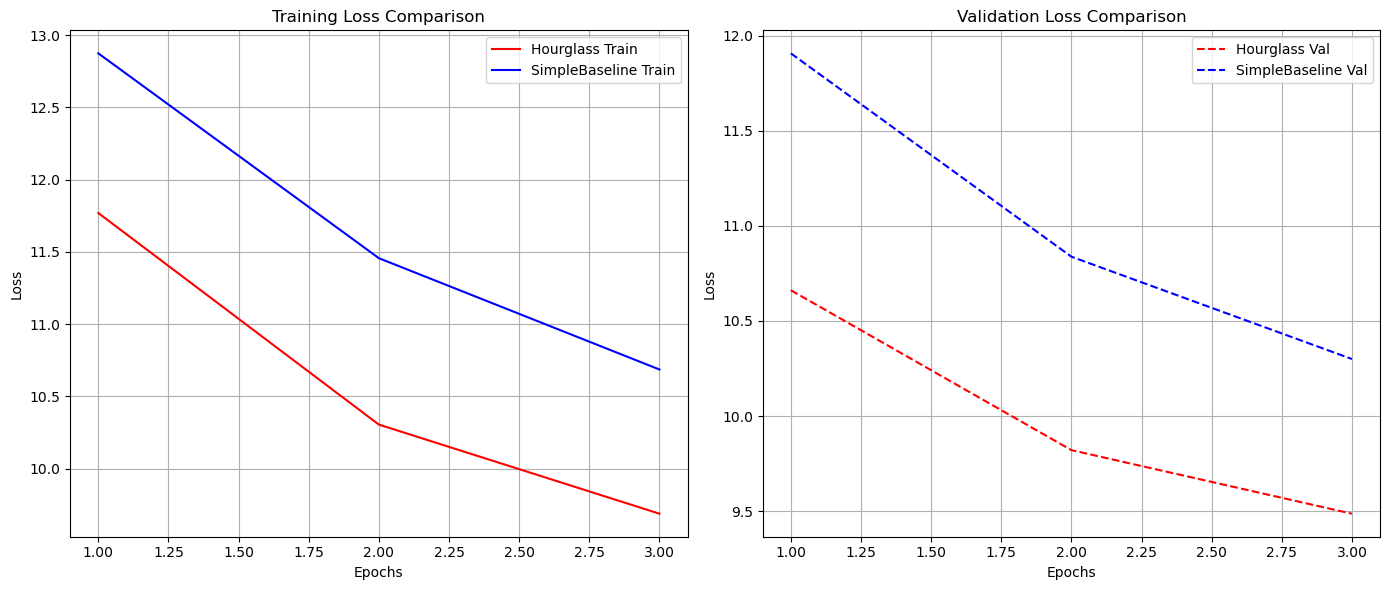

In [34]:
def plot_comparison(hg_history, sb_history):
    """
    hg_history: {'train': [...], 'val': [...]} 형태의 Hourglass 기록
    sb_history: {'train': [...], 'val': [...]} 형태의 SimpleBaseline 기록
    """
    epochs_hg = range(1, len(hg_history['train']) + 1)
    epochs_sb = range(1, len(sb_history['train']) + 1)

    plt.figure(figsize=(14, 6))

    # 1. Train Loss 비교
    plt.subplot(1, 2, 1)
    plt.plot(epochs_hg, hg_history['train'], 'r-', label='Hourglass Train')
    plt.plot(epochs_sb, sb_history['train'], 'b-', label='SimpleBaseline Train')
    plt.title('Training Loss Comparison')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    # 2. Validation Loss 비교
    plt.subplot(1, 2, 2)
    plt.plot(epochs_hg, hg_history['val'], 'r--', label='Hourglass Val')
    plt.plot(epochs_sb, sb_history['val'], 'b--', label='SimpleBaseline Val')
    plt.title('Validation Loss Comparison')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.savefig(PROJECT_PATH + 'model_comparison_plot.png') # 이미지 파일로 저장
    plt.show()

plot_comparison(hg_history, sb_history)

## 7. 모델 평가

In [35]:
# 학습된 모델 불러오기
def load_trained_model(model_type, checkpoint_path, num_heatmap=16):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    if model_type == 'hourglass':
        # Stacked Hourglass Network (우리가 학습시킨 구조와 동일하게 설정)
        model = StackedHourglassNetwork(IMAGE_SHAPE, num_stack=4, num_residual=1, num_heatmap=num_heatmap)
    else:
        # SimpleBaseline (Pretrained=False로 학습했으므로 로드할 때도 구조만 생성)
        model = SimpleBaseline(num_heatmap=num_heatmap, pretrained=False)
        
    # 가중치 로드
    if os.path.exists(checkpoint_path):
        checkpoint = torch.load(checkpoint_path, map_location=device)
        model.load_state_dict(checkpoint)
        model.to(device)
        model.eval() # 평가 모드 전환
        print(f"✅ {model_type} 모델 로드 성공: {checkpoint_path}")
        return model
    else:
        print(f"❌ 파일을 찾을 수 없습니다: {checkpoint_path}")
        return None

# 경로 지정
HG_MODEL_PATH = os.path.join(SAVE_DIR, "final_best_hourglass.pt")
SB_MODEL_PATH = os.path.join(SAVE_DIR, "final_best_simplebaseline.pt")

# 모델 로드
print("Evaluating models...")
model_hg = load_trained_model('hourglass', HG_MODEL_PATH, num_heatmap=NUM_HEATMAP)
model_sb = load_trained_model('simplebaseline', SB_MODEL_PATH, num_heatmap=NUM_HEATMAP)

Evaluating models...
✅ hourglass 모델 로드 성공: /home/jovyan/work/mpii/models/final_best_hourglass.pt
✅ simplebaseline 모델 로드 성공: /home/jovyan/work/mpii/models/final_best_simplebaseline.pt


### 7-1. Pose Estimation 결과 시각화

In [36]:
# 인덱스 매칭
R_ANKLE = 0
R_KNEE = 1
R_HIP = 2
L_HIP = 3
L_KNEE = 4
L_ANKLE = 5
PELVIS = 6
THORAX = 7
UPPER_NECK = 8
HEAD_TOP = 9
R_WRIST = 10
R_ELBOW = 11
R_SHOULDER = 12
L_SHOULDER = 13
L_ELBOW = 14
L_WRIST = 15

MPII_BONES = [
    [R_ANKLE, R_KNEE],
    [R_KNEE, R_HIP],
    [R_HIP, PELVIS],
    [L_HIP, PELVIS],
    [L_HIP, L_KNEE],
    [L_KNEE, L_ANKLE],
    [PELVIS, THORAX],
    [THORAX, UPPER_NECK],
    [UPPER_NECK, HEAD_TOP],
    [R_WRIST, R_ELBOW],
    [R_ELBOW, R_SHOULDER],
    [THORAX, R_SHOULDER],
    [THORAX, L_SHOULDER],
    [L_SHOULDER, L_ELBOW],
    [L_ELBOW, L_WRIST]
]

In [37]:
# 모델 학습을 heatmap으로 했기 때문에 추론 결과물도 heatmap
# heatmap의 최대값을 갖는 지점의 좌표를 추출
def find_max_coordinates(heatmaps):
    # heatmaps: (H, W, C)
    H, W, C = heatmaps.shape
    # reshape to (H*W, C)
    flatten_heatmaps = heatmaps.reshape(-1, C)
    # 각 채널 별 최대값 인덱스 (flattened index)
    indices = torch.argmax(flatten_heatmaps, dim=0)
    # y 좌표: index // H, x 좌표: index - H * y
    y = indices // H
    x = indices - H * y
    # 반환: (C, 2) 텐서, 각 행이 [x, y] 좌표
    return torch.stack([x, y], dim=1)

In [38]:
# 256x256 이미지에 64x64 heatmap max 값을 표현할 때 발생하는 quantization 오차를 방지
# 실제 계산에서는 3x3 필터를 이용해서 근사치를 구함
def extract_keypoints_from_heatmap(heatmaps):
    """
    heatmaps: (H, W, C) 텐서 (예: (64,64,16))
    """
    H, W, C = heatmaps.shape
    max_keypoints = find_max_coordinates(heatmaps)  # shape: (C, 2) with [x, y] per channel

    # pad heatmaps: 먼저 (C, H, W)로 변환한 후 pad, 다시 (H+2, W+2, C)
    heatmaps_permuted = heatmaps.permute(2, 0, 1)  # (C, H, W)
    padded = F.pad(heatmaps_permuted, (1, 1, 1, 1))  # pad (left, right, top, bottom)
    padded_heatmaps = padded.permute(1, 2, 0)  # (H+2, W+2, C)

    adjusted_keypoints = []
    for i, keypoint in enumerate(max_keypoints):
        # 기존 keypoint의 좌표에 패딩 오프셋 추가
        max_x = int(keypoint[0].item()) + 1
        max_y = int(keypoint[1].item()) + 1

        # 3x3 패치를 추출 (채널 i)
        patch = padded_heatmaps[max_y-1:max_y+2, max_x-1:max_x+2, i]  # (3,3)
        # 중앙 값 제거
        patch[1, 1] = 0
        # 패치 내 최대값의 index를 찾음
        flat_patch = patch.reshape(-1)
        index = torch.argmax(flat_patch).item()

        next_y = index // 3
        next_x = index % 3
        delta_y = (next_y - 1) / 4.0
        delta_x = (next_x - 1) / 4.0

        adjusted_x = keypoint[0].item() + delta_x
        adjusted_y = keypoint[1].item() + delta_y
        adjusted_keypoints.append((adjusted_x, adjusted_y))

    # 리스트를 텐서로 변환하고 clip
    adjusted_keypoints = torch.tensor(adjusted_keypoints)
    adjusted_keypoints = torch.clamp(adjusted_keypoints, 0, H)
    normalized_keypoints = adjusted_keypoints / H
    return normalized_keypoints

In [39]:
# keypoint 출력 함수 정의
def predict(model, image_path):
    # 이미지 로드 (RGB 모드)
    image = Image.open(image_path).convert("RGB")

    # 전처리: 리사이즈, 텐서 변환, [-1, 1] 범위로 스케일링
    preprocess = transforms.Compose([
        transforms.Resize((256, 256)),
        transforms.ToTensor(),         # 결과: [0, 1]
        transforms.Lambda(lambda x: x * 2 - 1)  # [0,1] -> [-1,1]
    ])
    inputs = preprocess(image)          # shape: (C, H, W)
    inputs = inputs.unsqueeze(0)        # 배치 차원 추가: (1, C, H, W)

    # 모델의 device에 맞게 입력을 이동시킵니다.
    device = next(model.parameters()).device
    inputs = inputs.to(device)

    model.eval()
    with torch.no_grad():
        outputs = model(inputs)         # outputs가 리스트가 아닐 수 있음

    if not isinstance(outputs, list):
        outputs = [outputs]

    # 마지막 스택의 결과를 사용한다고 가정 (출력 shape: (1, num_heatmap, H, W))
    heatmap_tensor = outputs[-1].squeeze(0)      # (num_heatmap, H, W)
    # extract_keypoints_from_heatmap 함수는 (H, W, num_heatmap) 형태를 기대하므로 차원 순서를 변경
    heatmap_tensor = heatmap_tensor.permute(1, 2, 0)  # (H, W, num_heatmap)

    # detach, CPU로 이동 후 extract_keypoints_from_heatmap에 전달
    heatmap = heatmap_tensor.detach().cpu()
    kp = extract_keypoints_from_heatmap(heatmap)

    return image, kp

In [40]:
def to_numpy_image(image):
    if torch.is_tensor(image):
        image_np = image.detach().cpu().numpy()
        # 이미지 채널이 첫 번째 차원이라면, (C, H, W) -> (H, W, C)
        if image_np.ndim == 3 and image_np.shape[0] == 3:
            image_np = np.transpose(image_np, (1, 2, 0))
    elif not isinstance(image, np.ndarray):
        # PIL.Image인 경우
        image_np = np.array(image)
    else:
        image_np = image
    return image_np

def compare_skeletons(image, kp_hg, kp_sb, title1="Hourglass", title2="SimpleBaseline"):
    image_np = to_numpy_image(image)
    # PIL 이미지인 경우 리사이즈 처리 (좌표가 0~1 사이이므로 크기 대응 필요)
    h, w, _ = image_np.shape

    fig, axes = plt.subplots(1, 2, figsize=(16, 8))
    all_kps = [kp_hg, kp_sb]
    titles = [title1, title2]

    for i, ax in enumerate(axes):
        ax.imshow(image_np)
        ax.set_title(titles[i], fontsize=15)
        
        # 현재 모델의 좌표 계산
        current_kp = all_kps[i]
        joints = []
        for joint in current_kp:
            joints.append((joint[0] * w, joint[1] * h))

        # 뼈대 그리기
        for bone in MPII_BONES:
            j1 = joints[bone[0]]
            j2 = joints[bone[1]]
            ax.plot([j1[0], j2[0]], [j1[1], j2[1]], linewidth=4, alpha=0.8)
            
        # 관절 점 찍기
        for jx, jy in joints:
            ax.scatter(jx, jy, s=20, c='white', edgecolors='red', zorder=3)
            
        ax.axis('off')

    plt.tight_layout()
    plt.show()

테스트 중...: test_image.jpg


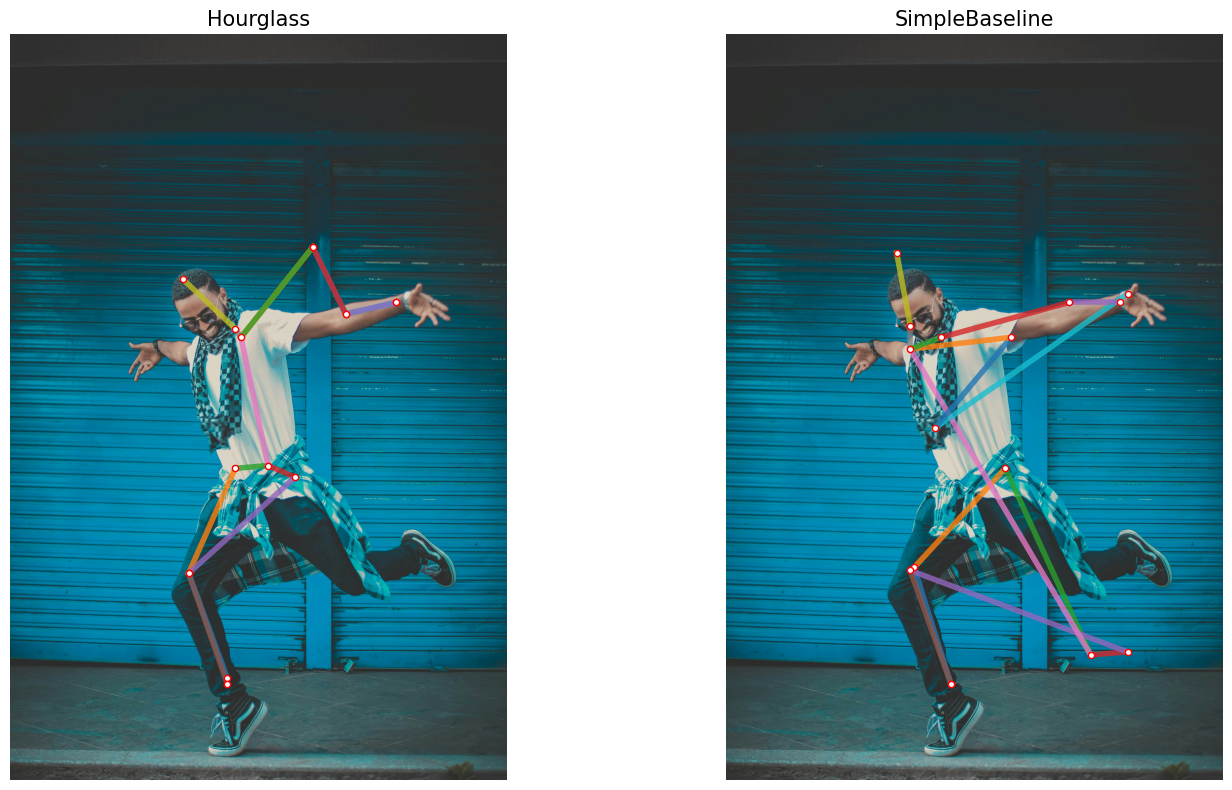

테스트 중...: test_image_2.jpg


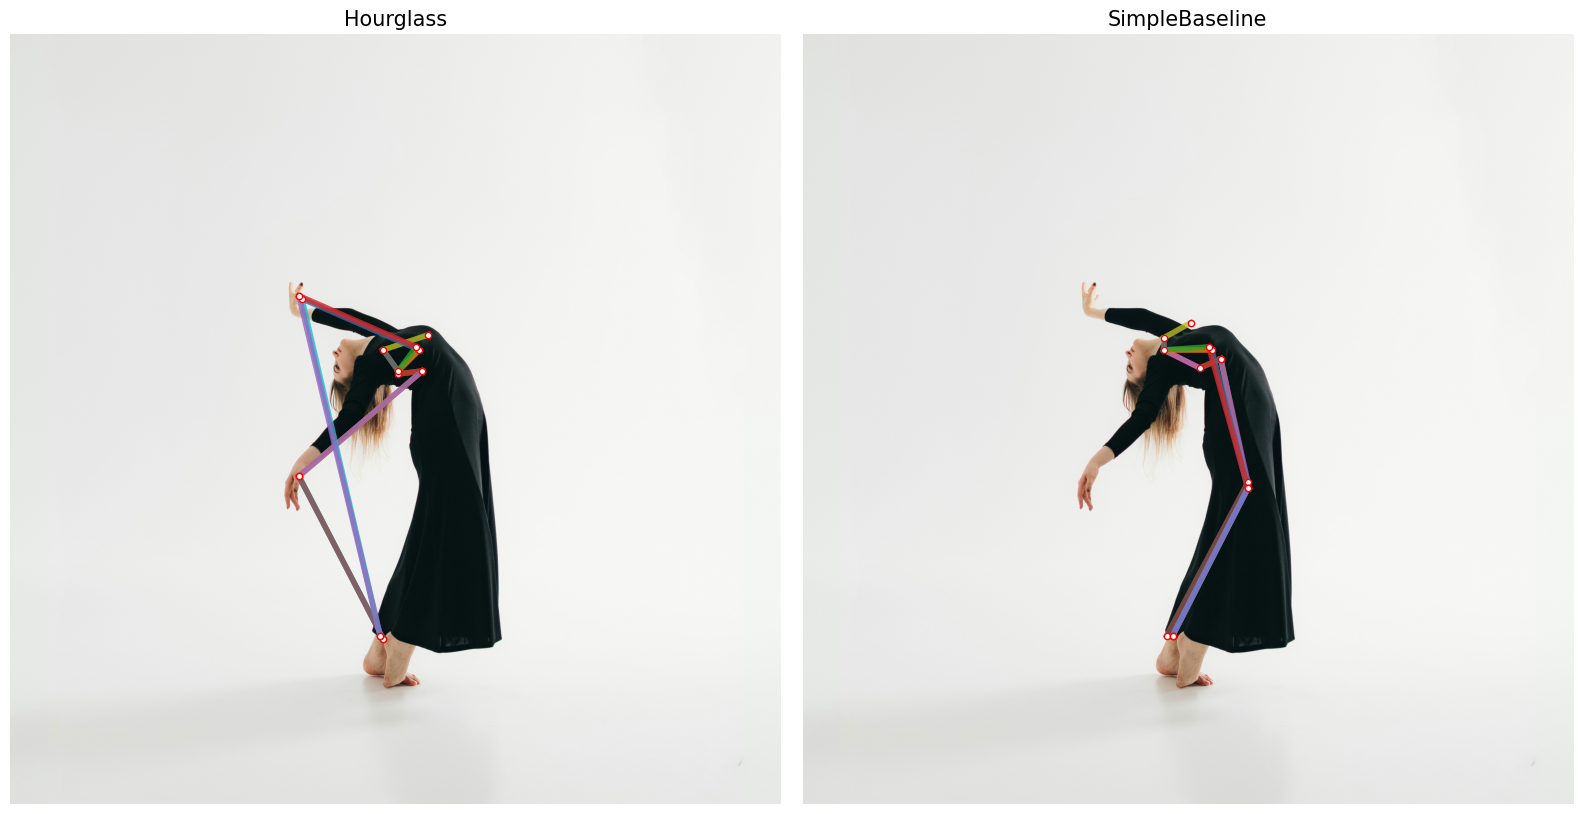

In [42]:
test_list = ["test_image.jpg", "test_image_2.jpg"]

for path in test_list:
    full_path = f"/home/jovyan/work/mpii/{path}"
    img, kh = predict(model_hg, full_path)
    _, ks = predict(model_sb, full_path)
    
    print(f"테스트 중...: {path}")
    compare_skeletons(img, kh, ks, title1="Hourglass", title2="SimpleBaseline")

### 7-2. XAI - Heatmap Overlay

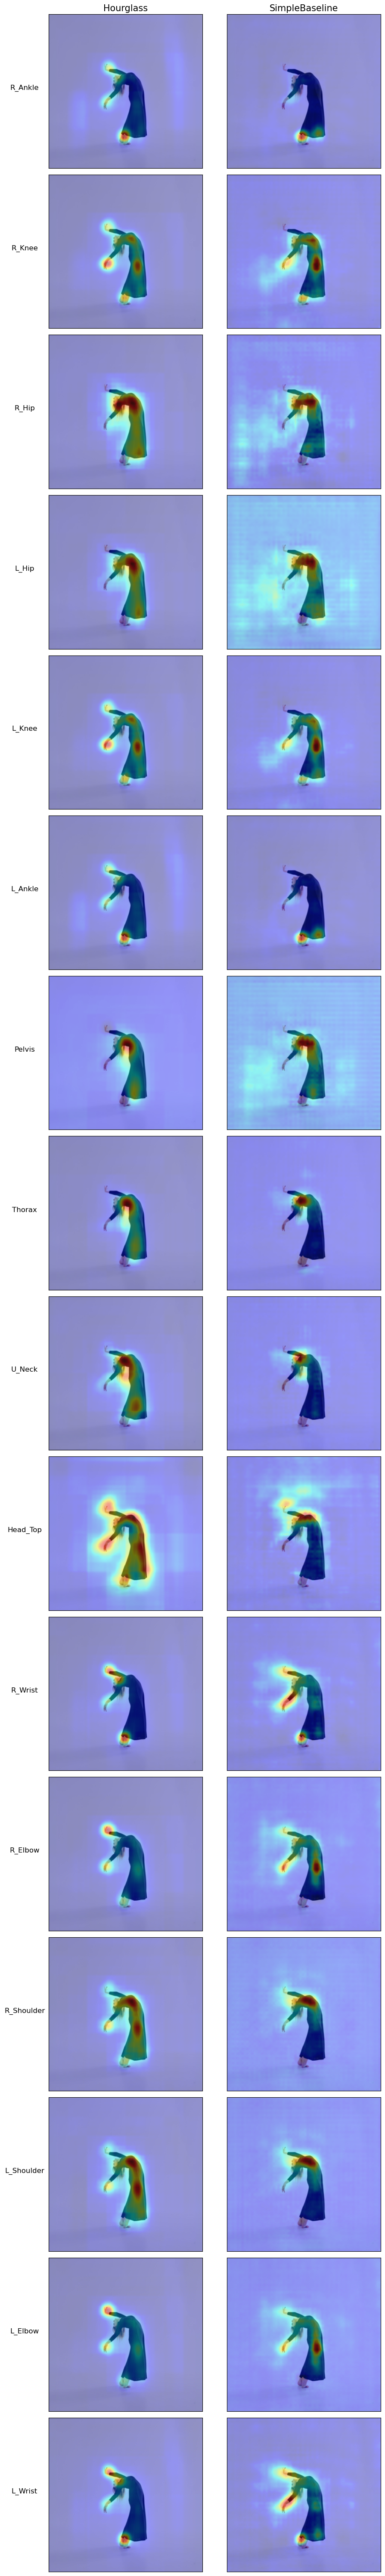

In [48]:
def compare_all_heatmaps(image, model1, model2, title1="Hourglass", title2="SimpleBaseline"):
    device = next(model1.parameters()).device
    model1.eval()
    model2.eval()
    
    # 1. 전처리
    input_tensor = transforms.Compose([
        transforms.Resize((256, 256)),
        transforms.ToTensor(),
        transforms.Lambda(lambda x: x * 2 - 1)
    ])(image).unsqueeze(0).to(device)

    # 2. 두 모델 예측
    with torch.no_grad():
        out1 = model1(input_tensor)
        out1 = out1[-1] if isinstance(out1, list) else out1
        out2 = model2(input_tensor)
        out2 = out2[-1] if isinstance(out2, list) else out2
    
    joint_names = [
        "R_Ankle", "R_Knee", "R_Hip", "L_Hip", "L_Knee", "L_Ankle",
        "Pelvis", "Thorax", "U_Neck", "Head_Top", "R_Wrist", "R_Elbow",
        "R_Shoulder", "L_Shoulder", "L_Elbow", "L_Wrist"
    ]

    # 3. 시각화 (16행 2열)
    fig, axes = plt.subplots(16, 2, figsize=(10, 60)) # 세로로 길게 배치
    origin_img = np.array(image.resize((256, 256)))

    for i in range(16):
        for j, (out, title) in enumerate(zip([out1, out2], [title1, title2])):
            ax = axes[i, j]
            
            # 히트맵 처리 및 오버레이 생성 (OpenCV 활용)
            hm = out[0, i].cpu().numpy()
            hm_resized = cv2.resize(hm, (256, 256))
            hm_norm = (hm_resized - hm_resized.min()) / (hm_resized.max() - hm_resized.min() + 1e-8)
            hm_color = cv2.applyColorMap(np.uint8(255 * hm_norm), cv2.COLORMAP_JET)
            hm_color = cv2.cvtColor(hm_color, cv2.COLOR_BGR2RGB)
            
            overlay = cv2.addWeighted(origin_img, 0.6, hm_color, 0.4, 0)
            
            ax.imshow(overlay)
            if i == 0: ax.set_title(title, fontsize=15)
            if j == 0: ax.set_ylabel(joint_names[i], fontsize=12, rotation=0, labelpad=40)
            ax.set_xticks([]); ax.set_yticks([])

    plt.tight_layout()
    plt.show()

# 실행
test_img = Image.open("test_image_2.jpg").convert("RGB")
compare_all_heatmaps(test_img, model_hg, model_sb)

## 정리

**1. 학습 곡선 (Loss Curve) 분석**

- Hourglass는 학습 초반부터 낮은 Loss에서 시작하여 안정적으로 하강하며 검증 Loss 9.48로 상당히 우수한 수렴 성능을 증명한다.

- SimpleBaseline은 사전 학습 가중치 없이 시작하여 학습 속도가 더디고 최종 검증 Loss 10.29에 그쳐 Hourglass의 1에폭 수준에 머무는 한계를 보인다.

- 결과적으로 Hourglass의 반복적인 정제(Stacked) 구조가 데이터 학습 효율성 면에서 훨씬 강력한 성능을 발휘함을 알 수 있었다.


**2. 테스트 이미지 (Skeleton) 비교**

- 역동적인 춤이나 유연한 요가 포즈처럼 관절이 겹치는 난도 높은 이미지에서 Hourglass는 인체의 해부학적 연결성을 유지하며 비교적 정확한 뼈대를 그려냈다.

- 반면 SimpleBaseline은 팔과 다리의 위치를 혼동하거나 관절 좌표가 이미지 밖으로 튀는 등 신체 구조를 파악하는 데 오류를 드러냈다.

- 이는 단순 레이어 적층 방식보다 다단계 예측 과정을 거치는 Hourglass가 복잡한 포즈의 맥락을 파악하는 능력이 월등함을 시사한다.


**3. 히트맵 오버레이 (Heatmap Overlay) 분석**

- Hourglass의 히트맵은 특정 관절 위치에 빨간색 점이 매우 작고 선명하게 집중되어 있어 모델의 예측 확신도가 매우 높음을 보여준다.

- SimpleBaseline의 히트맵은 반응 영역이 넓고 뿌옇게 퍼져 있으며, 배경의 노이즈에도 민감하게 반응하여 관절 위치 추론에 불확실성이 크다는 점이 드러난다.

## 회고

- 전체 데이터를 사용했을 때 학습 시간이 너무 오래 걸리기도 했고, Out of Memory 문제도 염려가 되어 학습 데이터셋 크기를 절반으로 줄였다. 본 프로젝트 목적은 모델 구조와 그에 따른 성능 차이를 비교하기 위함이었기 때문에 아주 큰 문제는 없을 것 같지만, 실무에서 최대한 많은 데이터셋으로 학습을 시키는 게 좋은 경우에 어떤 방법을 사용할 수 있을지 고민이다.


- 모델 학습까지 시간이 걸린 이유를 생각해보니 아직 실험 설정 경험이 부족하다는 결론이 났다. 설정을 여러 차례 바꾸느라 시간이 많이 흘렀는데, 다음 과제 수행 시 잊지 않기 위해 여기에 남겨본다.

  * 하이퍼파라미터 설정 전 시드 고정:
 
    보통 하이퍼파리미터 설정 후 DataLoader가 생성되는데, 이때 여러 모델이 학습할 데이터의 셔플링 순서까지 일치하게 되어 보다 공정한 실험이 가능
 
  * 모델을 여러 개 이어서 학습할 시 매 모델 학습이 시작되기 전 시드 고정:
 
    모델 객체를 생성할 때 부여되는 초기 가중치 값이 항정 일정하게 유지되어 재현성이 보장됨과 동시에 정밀한 실험 결과 판단이 가능
 
  * pretrained 가중치 사용 여부:
 
    2개 이상의 모델을 비교할 때 pretrained 가중치의 사용 여부가 과연 공정한 비교를 가능하게 할 수 있는지 생각!


- 참고 문헌:
  * [Newell, A., et al. (2016) [Stacked Hourglass]](https://arxiv.org/pdf/1603.06937)
    
  * [Xiao, B., et al. (2018) [Simple Baselines]](https://arxiv.org/pdf/1804.06208)

 
- 테스트 이미지 출처:

  * [test_image_2.jpg](https://unsplash.com/photos/a-woman-in-a-black-dress-is-doing-a-handstand-ZoyNDu4dvjo): Photo by <a href="https://unsplash.com/@ucolowa?utm_source=unsplash&utm_medium=referral&utm_content=creditCopyText">Natalya Ukolova</a> on <a href="https://unsplash.com/photos/a-woman-in-a-black-dress-is-doing-a-handstand-ZoyNDu4dvjo?utm_source=unsplash&utm_medium=referral&utm_content=creditCopyText">Unsplash</a>